### Purpose

Even after getting the sampling box working around the aurora, still have the SSD matrix looking kinda funny. Try to do some background subtraction with a running median for brightness (sliding box) to make the aurora / bright bits brighter relative to the background. Trying this specifically with the 5 UT event to begin with (with the larger and brighter aurora), then gonna try for the STEVE pickets in the 10 UT event. Also need to try out different methods of background subtraction besides this one. 

### Imports

In [1]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import xarray as xr

#for dealing with files:
import os
import re
from scipy.io import readsav
import h5py
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
from urllib.parse import urljoin, urlparse
import time

#for plotting (the rcParams updates are my personal perference to change font and increase fontsize)
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 24,\
                     'xtick.labelsize' : 24,\
                     'ytick.labelsize' : 24,\
                     'axes.titlesize' : 24,\
                     'axes.labelsize' : 24,\
                     'date.autoformatter.minute': '%H:%M' })

import skymap_data_helper # all helper functions for downloading and parsing data
import cv2 # for contrast adjustment
from PIL import Image # for resolution increase
import importlib
importlib.reload(skymap_data_helper)
import math

from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

import altitude_helper
import importlib
importlib.reload(altitude_helper)

import scipy.ndimage # needed for median_filter func, which calculates the running median 

### Load Data

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT
time_index = 251

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Setup (Projection)

In [43]:
H_REF = 300000 

site_name_yknf = "Yellowknife"
lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

site_name_fsmi = "Fort Smith"
lat_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_cam_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]


yknf_lat, yknf_lon = altitude_helper.new_spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf,
    lat_cam_yknf, lon_cam_yknf,
    H_REF
)

fsmi_lat, fsmi_lon = altitude_helper.new_spherical_project_lat_lon(
    full_azimuth_fsmi, full_elevation_fsmi,
    lat_cam_fsmi, lon_cam_fsmi,
    H_REF
)

### Running Median Background Subtraction (YKNF 5UT)
Take a box (defined by set of pixels) around in the image, find the median brightness of that window and keep it. Slide the box and keep collecting medians until have hit every pixel (each pixel is treated as a "center," so median_filter() returns an array of medians the same size as the original R/G/B channel 2D array of intensities. To handle edge cases (ie treating top left pixel as center pixel), uses mode='reflect' that wraps image about the x-axis, so it will take info from the opposite edge (ie top right pixel) to use as padding, so still get a full 200x200 sliding box. 

After getting this 2D array of medians, subtract the median from each original brightness. Should see the aurora become sharper against the gradient of the background.

Do contrast adjustment AFTER median filter!!

#### Implementation (200x200 box)

In [34]:
R_yknf = yknf_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_yknf = yknf_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_yknf = yknf_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)

h_target_arr = [200000]

box_size = 200 # 200x200 box, should be big enough for 480x553 image
start_time_200 = time.perf_counter()
R_background_map = scipy.ndimage.median_filter(R_yknf, size=box_size)
G_background_map = scipy.ndimage.median_filter(G_yknf, size=box_size)
B_background_map = scipy.ndimage.median_filter(B_yknf, size=box_size)

In [35]:
R_yknf_sub = R_yknf.astype(float) - R_background_map.astype(float)
R_yknf_sub = np.clip(R_yknf_sub, 0, None) #clip below zero (background become pure black)

G_yknf_sub = G_yknf.astype(float) - G_background_map.astype(float)
G_yknf_sub = np.clip(G_yknf_sub, 0, None)

B_yknf_sub = B_yknf.astype(float) - B_background_map.astype(float)
B_yknf_sub = np.clip(B_yknf_sub, 0, None)

end_time_200 = time.perf_counter()

rgb_yknf_sub_200 = np.stack([R_yknf_sub, G_yknf_sub, B_yknf_sub], axis=-1)

#### Implementation (thin vertical sliding box)
Had to change to constant rather than reflection mode, and shorten the box

In [36]:
vert_box = (int(R_yknf.shape[0]/2), 10)
start_time_vert = time.perf_counter()
R_background_map = scipy.ndimage.median_filter(R_yknf, size=vert_box, mode='constant', cval=0.0)
G_background_map = scipy.ndimage.median_filter(G_yknf, size=vert_box, mode='constant', cval=0.0)
B_background_map = scipy.ndimage.median_filter(B_yknf, size=vert_box, mode='constant', cval=0.0)

In [37]:
R_yknf_sub = R_yknf.astype(float) - R_background_map.astype(float)
R_yknf_sub = np.clip(R_yknf_sub, 0, None)

G_yknf_sub = G_yknf.astype(float) - G_background_map.astype(float)
G_yknf_sub = np.clip(G_yknf_sub, 0, None)

B_yknf_sub = B_yknf.astype(float) - B_background_map.astype(float)
B_yknf_sub = np.clip(B_yknf_sub, 0, None)

end_time_vert = time.perf_counter() 

rgb_yknf_sub_vert = np.stack([R_yknf_sub, G_yknf_sub, B_yknf_sub], axis=-1)

#### Plot original vs background subtracted

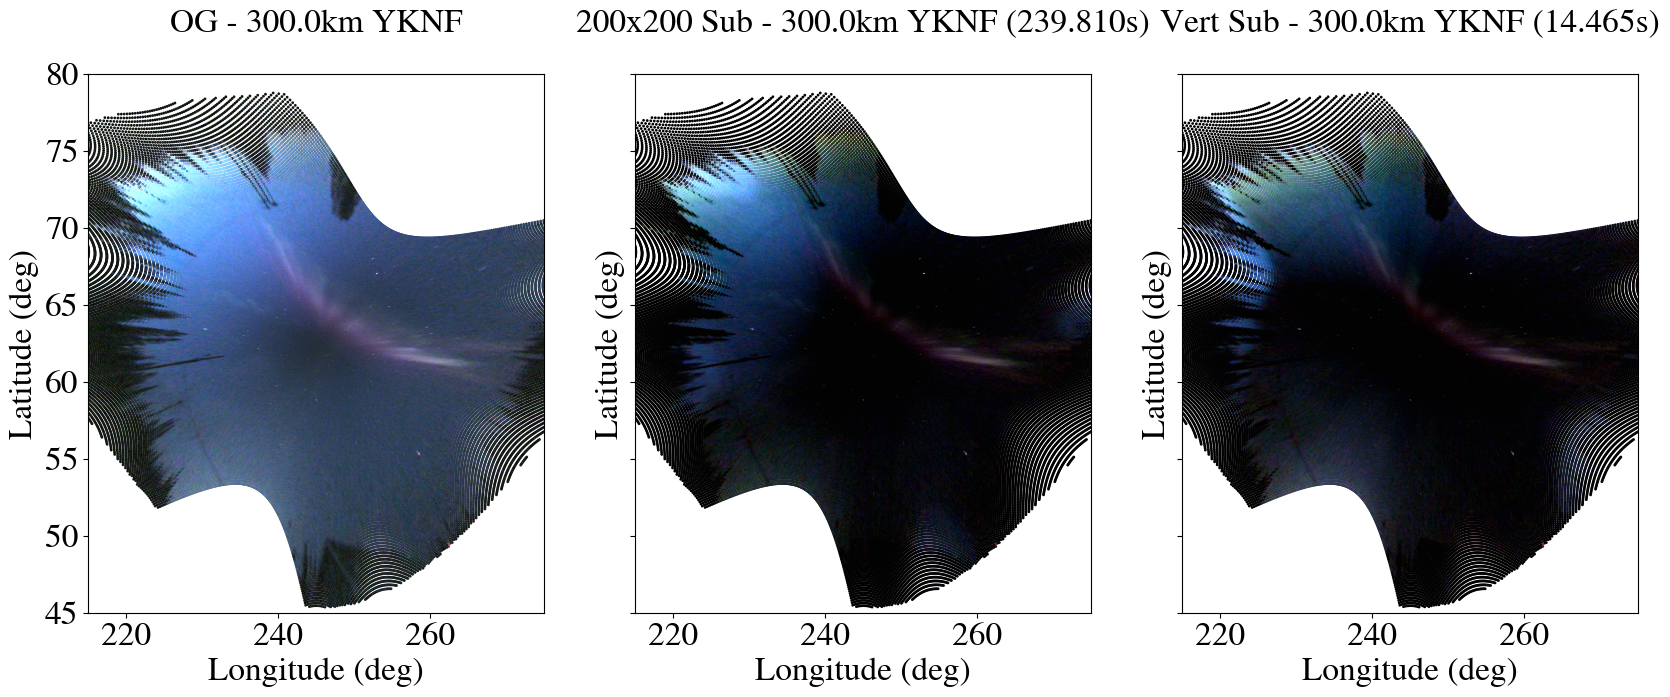

In [38]:
# plot after background subtraction on each r, g, b channel individually 
x_plot_min = 215
x_plot_max = 275
y_plot_min = 45
y_plot_max = 80

alpha = 5 # Increase this if it's still too dark
beta = -2
rgb_yknf_sub_200_adjusted = cv2.convertScaleAbs(rgb_yknf_sub_200, alpha=alpha, beta=beta)
rgb_yknf_sub_vert_adjusted = cv2.convertScaleAbs(rgb_yknf_sub_vert, alpha=alpha, beta=beta)
rgb_yknf_adjusted = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta)

raw_time = yknf_rgb_asi_ds.times.values[time_index]
time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")

runtime_200 = end_time_200 - start_time_200
runtime_vert = end_time_vert - start_time_vert

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 7), sharey=True)

ax1.scatter(yknf_lon.flatten(),yknf_lat.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1)
ax1.set_xlim((x_plot_min, x_plot_max))
ax1.set_ylim((y_plot_min, y_plot_max))
ax1.set_ylabel("Latitude (deg)")
ax1.set_xlabel("Longitude (deg)")
ax1.set_title(f"OG - {H_REF/1000}km YKNF", pad=30);

ax2.scatter(yknf_lon.flatten(),yknf_lat.flatten(),c=rgb_yknf_sub_200_adjusted.reshape(-1, 3)/256,s=1)
ax2.set_xlim((x_plot_min, x_plot_max))
ax2.set_ylim((y_plot_min, y_plot_max))
ax2.set_ylabel("Latitude (deg)")
ax2.set_xlabel("Longitude (deg)")
ax2.set_title(f"200x200 Sub - {H_REF/1000}km YKNF ({runtime_200:.3f}s)", pad=30);

ax3.scatter(yknf_lon.flatten(),yknf_lat.flatten(),c=rgb_yknf_sub_vert_adjusted.reshape(-1, 3)/256,s=1)
ax3.set_xlim((x_plot_min, x_plot_max))
ax3.set_ylim((y_plot_min, y_plot_max))
ax3.set_ylabel("Latitude (deg)")
ax3.set_xlabel("Longitude (deg)")
ax3.set_title(f"Vert Sub - {H_REF/1000}km YKNF ({runtime_vert:.3f}s)", pad=30);

plt.show()

### Speeding Up Running Median (YKNF 5UT)
For purposes of running for the , want to try downsampling (cv2.resize with interpolation=INTER_AREA), doing the running median, then upsampling again. 

downsample --> separate into channels --> perofrm operation on each channel --> upsample individual channels --> merge channesl

In [39]:
start_time_vert = time.perf_counter()

rgb_yknf_downsampled = cv2.resize(rgb_yknf, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
R_yknf_downsampled, G_yknf_downsampled, B_yknf_downsampled = cv2.split(rgb_yknf_downsampled)

#plt.imshow(rgb_yknf_downsampled)

In [40]:
vert_box = (int(R_yknf_downsampled.shape[0]/2), 10)
R_background_map = scipy.ndimage.median_filter(R_yknf_downsampled, size=vert_box, mode='constant', cval=0.0)
G_background_map = scipy.ndimage.median_filter(G_yknf_downsampled, size=vert_box, mode='constant', cval=0.0)
B_background_map = scipy.ndimage.median_filter(B_yknf_downsampled, size=vert_box, mode='constant', cval=0.0)

In [41]:
R_yknf_sub_down = R_yknf_downsampled.astype(float) - R_background_map.astype(float)
R_yknf_sub_down = np.clip(R_yknf_sub_down, 0, None)
R_yknf_sub = cv2.resize(R_yknf_sub_down, (553, 480), interpolation=cv2.INTER_CUBIC)

G_yknf_sub_down = G_yknf_downsampled.astype(float) - G_background_map.astype(float)
G_yknf_sub_down = np.clip(G_yknf_sub_down, 0, None)
G_yknf_sub = cv2.resize(G_yknf_sub_down, (553, 480), interpolation=cv2.INTER_CUBIC)

B_yknf_sub_down = B_yknf_downsampled.astype(float) - B_background_map.astype(float)
B_yknf_sub_down = np.clip(B_yknf_sub_down, 0, None)
B_yknf_sub = cv2.resize(B_yknf_sub_down, (553, 480), interpolation=cv2.INTER_CUBIC)

end_time_vert = time.perf_counter() 
rgb_yknf_sub_vert = np.stack([R_yknf_sub, G_yknf_sub, B_yknf_sub], axis=-1)

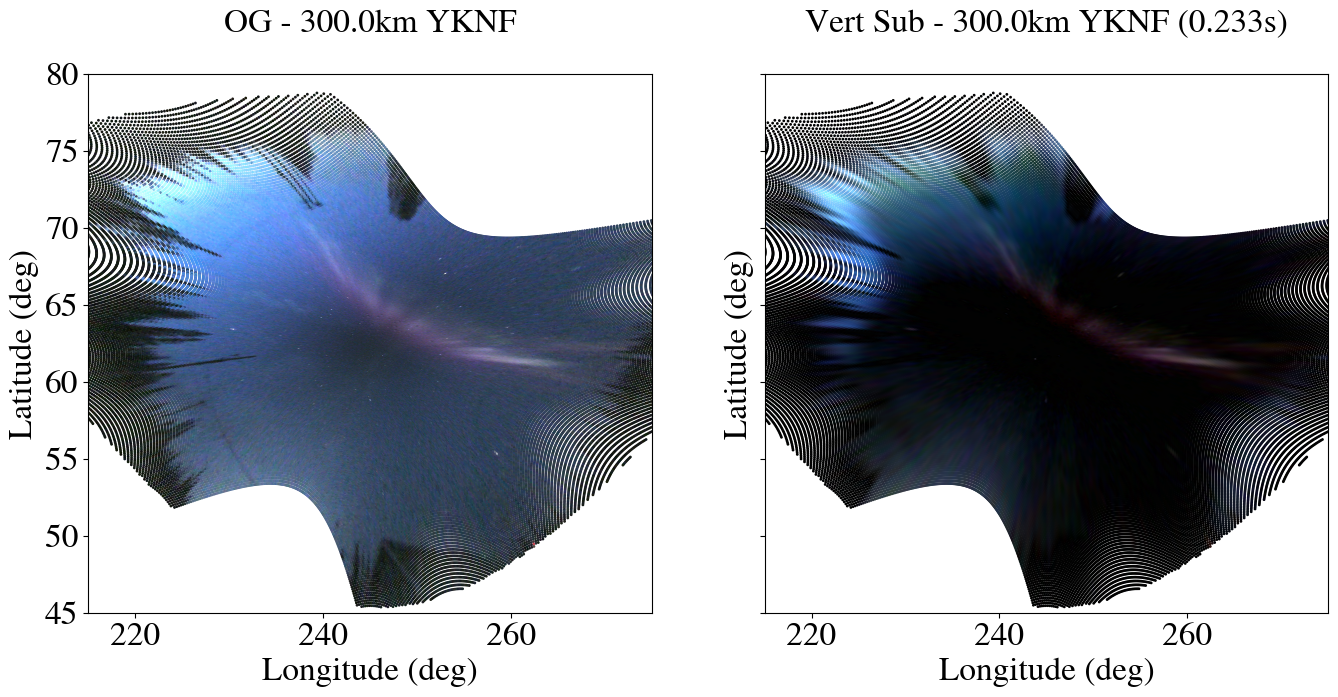

In [42]:
# plot after background subtraction on each r, g, b channel individually 
x_plot_min = 215
x_plot_max = 275
y_plot_min = 45
y_plot_max = 80

alpha = 5 # Increase this if it's still too dark
beta = -2
rgb_yknf_sub_vert_adjusted = cv2.convertScaleAbs(rgb_yknf_sub_vert, alpha=alpha, beta=beta)
rgb_yknf_adjusted = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta)

raw_time = yknf_rgb_asi_ds.times.values[time_index]
time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")

runtime_vert = end_time_vert - start_time_vert

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

ax1.scatter(yknf_lon.flatten(),yknf_lat.flatten(),c=rgb_yknf_adjusted.reshape(-1, 3)/256,s=1)
ax1.set_xlim((x_plot_min, x_plot_max))
ax1.set_ylim((y_plot_min, y_plot_max))
ax1.set_ylabel("Latitude (deg)")
ax1.set_xlabel("Longitude (deg)")
ax1.set_title(f"OG - {H_REF/1000}km YKNF", pad=30);

ax3.scatter(yknf_lon.flatten(),yknf_lat.flatten(),c=rgb_yknf_sub_vert_adjusted.reshape(-1, 3)/256,s=1)
ax3.set_xlim((x_plot_min, x_plot_max))
ax3.set_ylim((y_plot_min, y_plot_max))
ax3.set_ylabel("Latitude (deg)")
ax3.set_xlabel("Longitude (deg)")
ax3.set_title(f"Vert Sub - {H_REF/1000}km YKNF ({runtime_vert:.3f}s)", pad=30);

plt.show()

### Running Median Background Subtraction (FSMI 5UT)
Only do the vertical box + sped up version to see (same setup as yknf), if bad then think again. 

In [45]:
R_fsmi = fsmi_rgb_asi_ds.image.sel(channel="R").isel(times=time_index).values
G_fsmi = fsmi_rgb_asi_ds.image.sel(channel="G").isel(times=time_index).values
B_fsmi = fsmi_rgb_asi_ds.image.sel(channel="B").isel(times=time_index).values
rgb_fsmi = np.stack([R_fsmi, G_fsmi, B_fsmi], axis=-1)

start_time_vert = time.perf_counter()

rgb_fsmi_downsampled = cv2.resize(rgb_fsmi, None, fx=0.25, fy=0.25, interpolation=cv2.INTER_AREA)
R_fsmi_downsampled, G_fsmi_downsampled, B_fsmi_downsampled = cv2.split(rgb_fsmi_downsampled)

In [46]:
vert_box = (int(R_fsmi_downsampled.shape[0]/2), 10)
R_background_map = scipy.ndimage.median_filter(R_fsmi_downsampled, size=vert_box, mode='constant', cval=0.0)
G_background_map = scipy.ndimage.median_filter(G_fsmi_downsampled, size=vert_box, mode='constant', cval=0.0)
B_background_map = scipy.ndimage.median_filter(B_fsmi_downsampled, size=vert_box, mode='constant', cval=0.0)

In [47]:
R_fsmi_sub_down = R_fsmi_downsampled.astype(float) - R_background_map.astype(float)
R_fsmi_sub_down = np.clip(R_fsmi_sub_down, 0, None)
R_fsmi_sub = cv2.resize(R_fsmi_sub_down, (553, 480), interpolation=cv2.INTER_CUBIC)

G_fsmi_sub_down = G_fsmi_downsampled.astype(float) - G_background_map.astype(float)
G_fsmi_sub_down = np.clip(G_fsmi_sub_down, 0, None)
G_fsmi_sub = cv2.resize(G_fsmi_sub_down, (553, 480), interpolation=cv2.INTER_CUBIC)

B_fsmi_sub_down = B_fsmi_downsampled.astype(float) - B_background_map.astype(float)
B_fsmi_sub_down = np.clip(B_fsmi_sub_down, 0, None)
B_fsmi_sub = cv2.resize(B_fsmi_sub_down, (553, 480), interpolation=cv2.INTER_CUBIC)

end_time_vert = time.perf_counter() 

rgb_fsmi_sub_vert = np.stack([R_fsmi_sub, G_fsmi_sub, B_fsmi_sub], axis=-1)

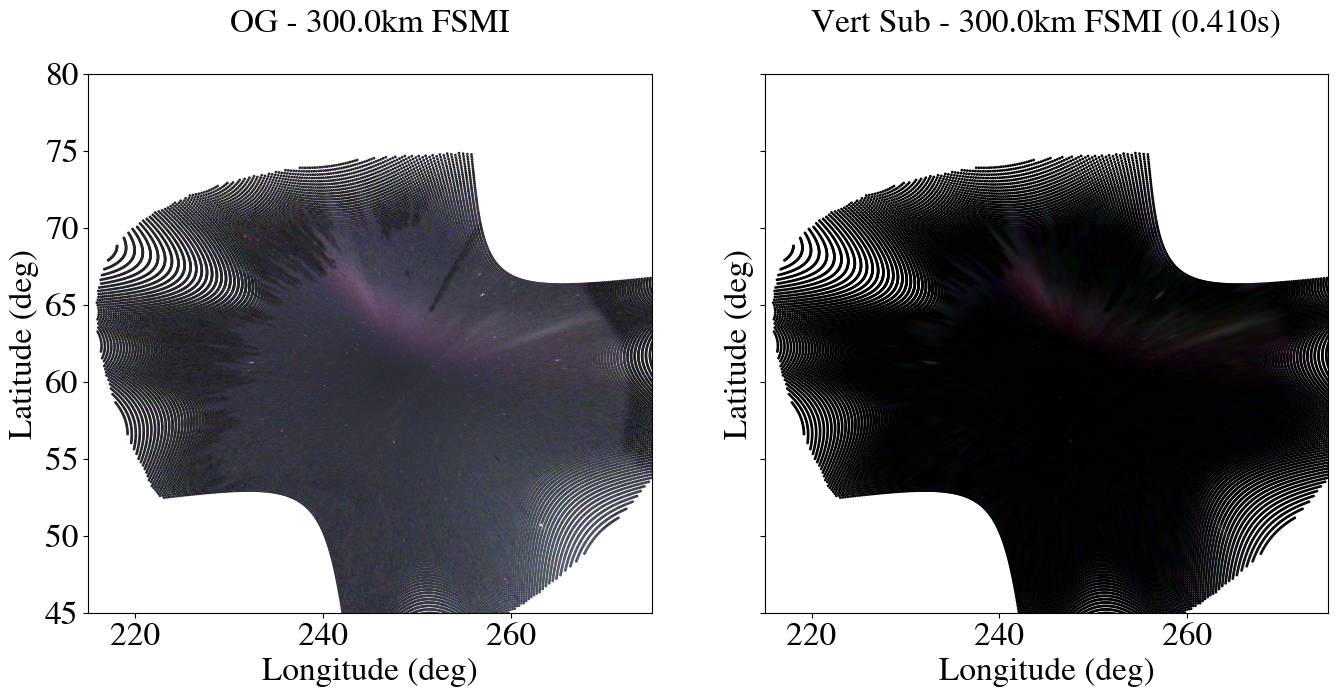

In [48]:
# plot after background subtraction on each r, g, b channel individually 
x_plot_min = 215
x_plot_max = 275
y_plot_min = 45
y_plot_max = 80

alpha = 5 # Increase this if it's still too dark
beta = -2
rgb_fsmi_sub_vert_adjusted = cv2.convertScaleAbs(rgb_fsmi_sub_vert, alpha=alpha, beta=beta)
rgb_fsmi_adjusted = cv2.convertScaleAbs(rgb_fsmi, alpha=alpha, beta=beta)

raw_time = fsmi_rgb_asi_ds.times.values[time_index]
time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")

runtime_vert = end_time_vert - start_time_vert

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

ax1.scatter(fsmi_lon.flatten(),fsmi_lat.flatten(),c=rgb_fsmi_adjusted.reshape(-1, 3)/256,s=1)
ax1.set_xlim((x_plot_min, x_plot_max))
ax1.set_ylim((y_plot_min, y_plot_max))
ax1.set_ylabel("Latitude (deg)")
ax1.set_xlabel("Longitude (deg)")
ax1.set_title(f"OG - {H_REF/1000}km FSMI", pad=30);

ax3.scatter(fsmi_lon.flatten(),fsmi_lat.flatten(),c=rgb_fsmi_sub_vert_adjusted.reshape(-1, 3)/256,s=1)
ax3.set_xlim((x_plot_min, x_plot_max))
ax3.set_ylim((y_plot_min, y_plot_max))
ax3.set_ylabel("Latitude (deg)")
ax3.set_xlabel("Longitude (deg)")
ax3.set_title(f"Vert Sub - {H_REF/1000}km FSMI ({runtime_vert:.3f}s)", pad=30);

plt.show()

### Top Hat Filter (10 UT FSMI)